In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score,StratifiedKFold,GridSearchCV
from sklearn.metrics import classification_report,accuracy_score,precision_score,r2_score,confusion_matrix,roc_auc_score,recall_score,precision_recall_curve
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler,OneHotEncoder,PolynomialFeatures
from imblearn.under_sampling import RandomUnderSampler

In [2]:
os.getcwd()
os.listdir('/kaggle/input/')

['datasets']

In [3]:
df=pd.read_csv("/kaggle/input/datasets/felicitychinaza/credit-card-detection/credit_card_fraud_10k.csv")
#first 10 rows
df.head()[:10]


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [4]:
#check data type
df.info()
#check statistic summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [5]:
#checks of missing values
df.isna().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [6]:
#column list
df.columns.tolist()

['transaction_id',
 'amount',
 'transaction_hour',
 'merchant_category',
 'foreign_transaction',
 'location_mismatch',
 'device_trust_score',
 'velocity_last_24h',
 'cardholder_age',
 'is_fraud']

In [7]:
#total amount made from macrchant 
df.groupby("merchant_category")[['amount']].mean().rename(columns={'amount':'Average_Amount'})

,Average_Amount
merchant_category,
Clothing,176.015478
Electronics,178.606058
Food,173.832226
Grocery,176.724594
Travel,174.785854


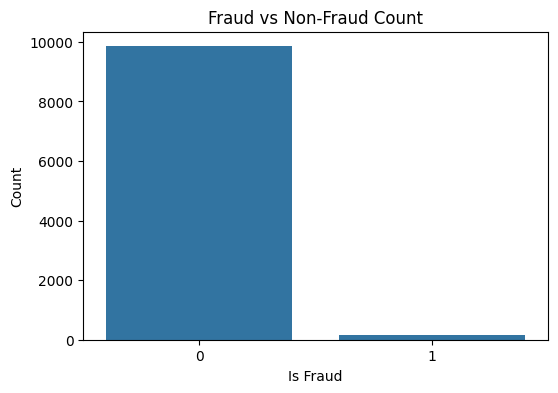

In [8]:
#correlation
import seaborn as sns
import matplotlib.pyplot as plt

fig=plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Non-Fraud Count")
plt.xlabel("Is Fraud")
plt.ylabel("Count")
plt.show()
fig.savefig('fraudvsnon-fraudcount.png')


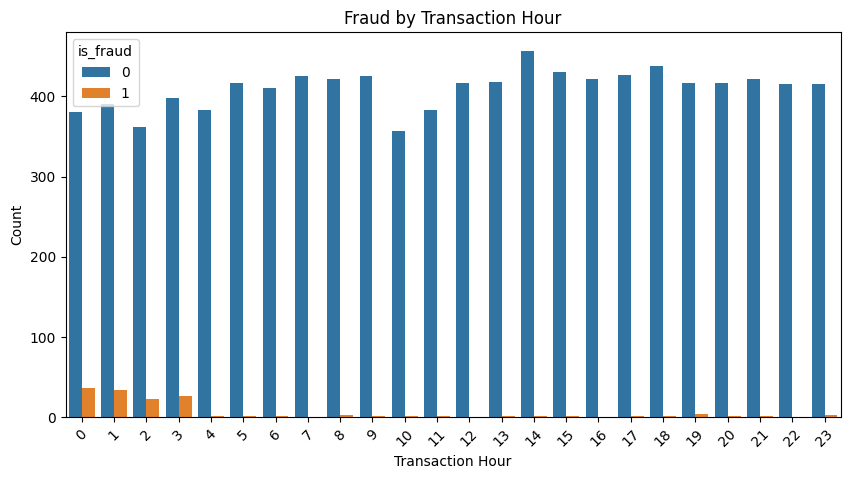

In [9]:
fig=plt.figure(figsize=(10,5))
sns.countplot(x='transaction_hour', hue='is_fraud', data=df)
plt.title("Fraud by Transaction Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()
fig.savefig('FraudbyTransaction.png')

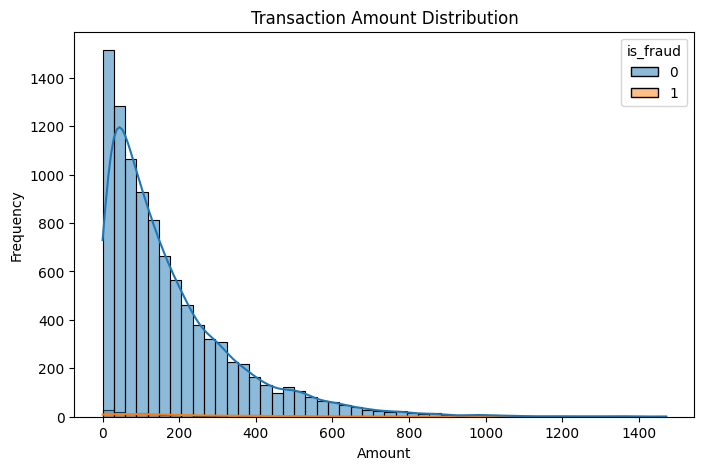

In [10]:
fig=plt.figure(figsize=(8,5))
sns.histplot(data=df, x='amount', hue='is_fraud', kde=True, bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()
fig.savefig('TransactionAmount.png')

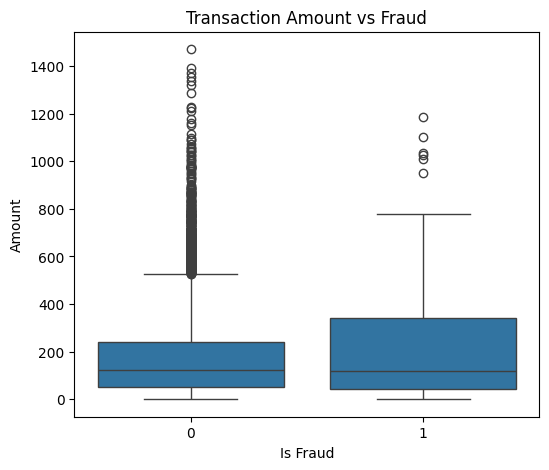

In [11]:
fig=plt.figure(figsize=(6,5))
sns.boxplot(x='is_fraud', y='amount', data=df)
plt.title("Transaction Amount vs Fraud")
plt.xlabel("Is Fraud")
plt.ylabel("Amount")
plt.show()
fig.savefig('TransactionAmountbyFraud.png')

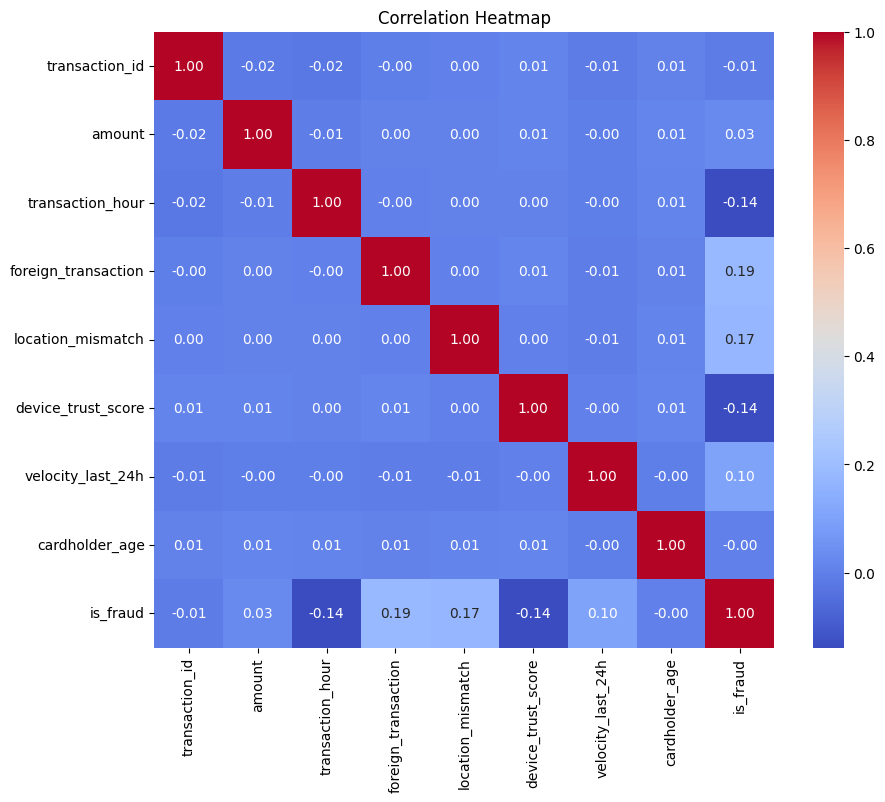

In [12]:
fig=plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
fig.savefig('correlationHeatmap.png')

In [13]:
#check for imbalanced target
df['is_fraud'].value_counts(normalize=True)*100


is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64

In [14]:
#split dataset
x=df.drop(columns='is_fraud',axis=1)
y=df.is_fraud

#encode dato
ohe=OneHotEncoder(drop='first',sparse_output=False)
ME=ohe.fit_transform(df[['merchant_category']])
merchant_encoded_df = pd.DataFrame(ME, columns=ohe.get_feature_names_out(['merchant_category']))
x = x.drop('merchant_category', axis=1)  # remove original column
x = pd.concat([x.reset_index(drop=True), merchant_encoded_df.reset_index(drop=True)], axis=1)


#Train dataset
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=41)
#solving imbalance data
RUS=RandomUnderSampler(random_state=42)
x_train_RUS,y_train_RUS=RUS.fit_resample(x_train,y_train)

#pedict the the test
model=RandomForestClassifier(random_state=42)
model_rf=model.fit(x_train_RUS,y_train_RUS)
#predict model
y_pred=model.predict(x_test)


In [15]:
#evaluate report
print("classification_report\n:", classification_report(y_pred,y_test))
print("r2_score\n:", r2_score(y_pred,y_test))
print('recall\n:',recall_score(y_pred,y_test))
print('precision\n:',precision_score(y_pred,y_test))

classification_report
:               precision    recall  f1-score   support

           0       0.92      1.00      0.96      2713
           1       1.00      0.18      0.31       287

    accuracy                           0.92      3000
   macro avg       0.96      0.59      0.63      3000
weighted avg       0.93      0.92      0.90      3000

r2_score
: 0.0945646911052862
recall
: 0.18118466898954705
precision
: 1.0


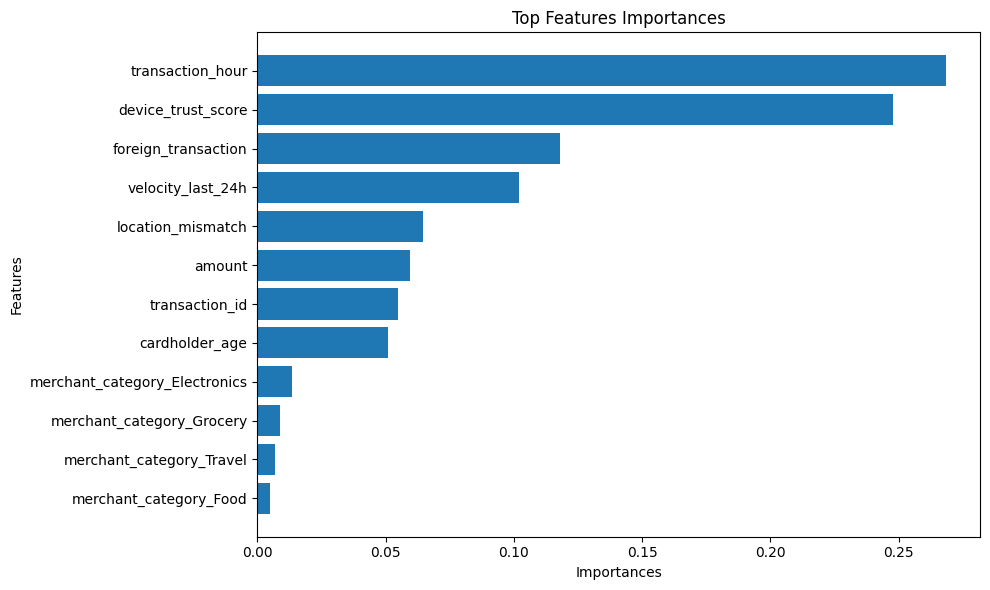

In [16]:
#Key influencer
importances=model.feature_importances_
features=x.columns
#top Features
df4=pd.DataFrame({'Features':features,'Importance':importances})
df4=df4.sort_values(by='Importance',ascending=True)

fig=plt.figure(figsize=(10,6))
plt.barh(df4['Features'],df4['Importance'])
plt.xlabel("Importances")
plt.ylabel("Features")
plt.title("Top Features Importances")
plt.tight_layout()
plt.show()
fig.savefig('FeaturesImportance.png')

In [17]:
#Logistic Regression
lr= LogisticRegression(max_iter=1000,random_state=40)
model_lr=lr.fit(x_train_RUS,y_train_RUS)
y_predict=lr.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
#evaluate model
print("classification_report\n:", classification_report(y_predict,y_test))
print("r2_score\n:", r2_score(y_predict,y_test))
print('recall\n:',recall_score(y_predict,y_test))
print('precision\n:',precision_score(y_pred,y_test))

classification_report
:               precision    recall  f1-score   support

           0       0.93      1.00      0.96      2751
           1       0.92      0.19      0.32       249

    accuracy                           0.93      3000
   macro avg       0.93      0.60      0.64      3000
weighted avg       0.93      0.93      0.91      3000

r2_score
: 0.10218847034813217
recall
: 0.1927710843373494
precision
: 1.0


In [19]:
cof=lr.coef_[0]
intercept= lr.intercept_
#create a data frame
df3=pd.DataFrame({'Features':x.columns, 'coefficient':cof})

#sort by Absolute IMportance
df3['Abs_coff']=np.abs(df3['coefficient'])
df3=df3.sort_values(by='Abs_coff',ascending=True)

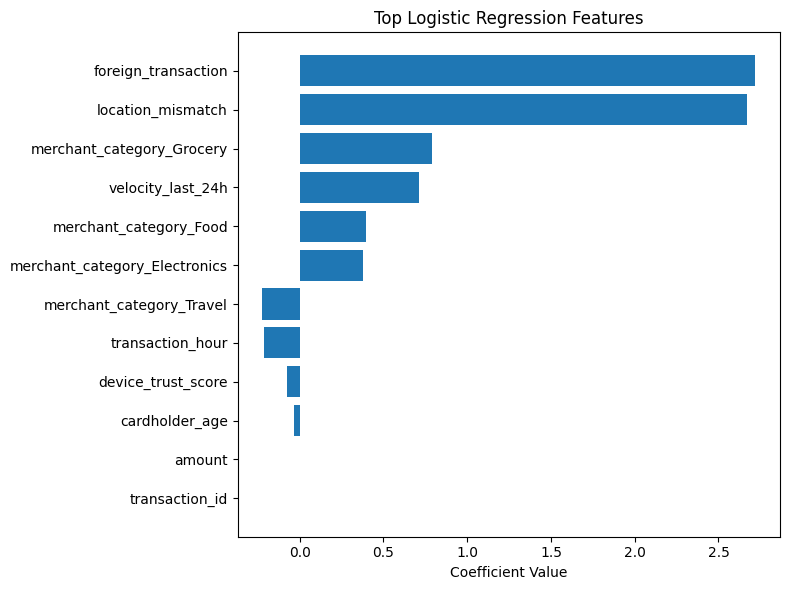

In [20]:
top_features =df3.head(15)

fig=plt.figure(figsize=(8,6))
plt.barh(top_features['Features'], top_features['coefficient'])
plt.title("Top Logistic Regression Features")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()
fig.savefig('LogisticRegressionFeatures.png')

In [21]:
#cv for better generalization
rf=RandomForestClassifier(random_state=42)
sd=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_m=cross_val_score(rf,x_train_RUS,y_train_RUS,cv=sd,scoring="accuracy")


In [22]:
#Hypertuning
para_grid={'n_estimators': [50,100],
    'max_depth': [None,7, 10],
    'min_samples_split': [2, 5],
          'min_samples_leaf':[1,2],
          'max_features':['sqrt']}
    

Grid_search=GridSearchCV(rf,
                          para_grid,
                          cv=sd,
                          scoring='recall',
                          n_jobs=-1)

In [23]:
#fit
Grid_search.fit(x_train_RUS,y_train_RUS)
print(Grid_search.best_params_)

#predict
lyp=Grid_search.best_estimator_
y_preds=lyp.predict(x_test)
y_prob = lyp.predict_proba(x_test)[:,1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_preds))
print("\nClassification Report:\n", classification_report(y_test, y_preds))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Confusion Matrix:
 [[2713  235]
 [   0   52]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96      2948
           1       0.18      1.00      0.31        52

    accuracy                           0.92      3000
   macro avg       0.59      0.96      0.63      3000
weighted avg       0.99      0.92      0.95      3000


ROC-AUC Score: 0.9934049159795428


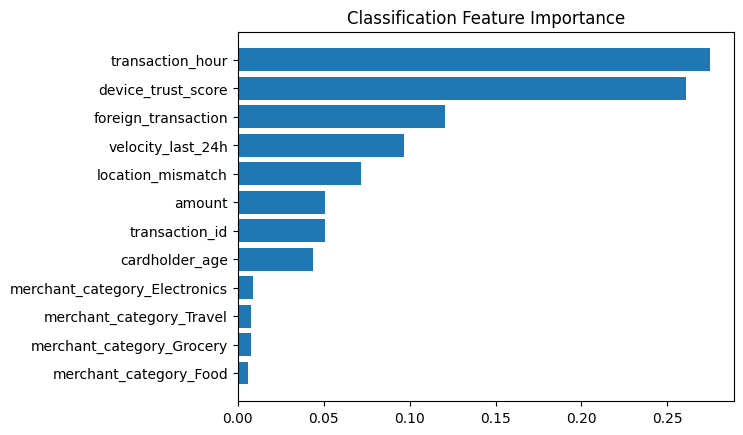

In [24]:
Feature=x_train_RUS.columns
importances_clf = lyp.feature_importances_
df6=pd.DataFrame({'Features':Feature,'Importances':importances_clf})
df6=df6.sort_values(by='Importances',ascending=True)
plt.barh(df6['Features'], df6['Importances'])
plt.title("Classification Feature Importance")
plt.show()


In [25]:
y_prob = lyp.predict_proba(x_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    y_pred_custom =(y_prob >= t).astype(int)
    print(f'threshold:{t:2f}')
    print("Precision:", precision_score(y_test, y_pred_custom))
    print("Recall:", recall_score(y_test, y_pred_custom))
    print("-------------------")

threshold:0.100000
Precision: 0.033121019108280254
Recall: 1.0
-------------------
threshold:0.150000
Precision: 0.0387192851824274
Recall: 1.0
-------------------
threshold:0.200000
Precision: 0.04569420035149385
Recall: 1.0
-------------------
threshold:0.250000
Precision: 0.06168446026097272
Recall: 1.0
-------------------
threshold:0.300000
Precision: 0.08360128617363344
Recall: 1.0
-------------------
threshold:0.350000
Precision: 0.1078838174273859
Recall: 1.0
-------------------
threshold:0.400000
Precision: 0.12839506172839507
Recall: 1.0
-------------------
threshold:0.450000
Precision: 0.15384615384615385
Recall: 1.0
-------------------
threshold:0.500000
Precision: 0.18118466898954705
Recall: 1.0
-------------------
threshold:0.550000
Precision: 0.22972972972972974
Recall: 0.9807692307692307
-------------------
threshold:0.600000
Precision: 0.2916666666666667
Recall: 0.9423076923076923
-------------------
threshold:0.650000
Precision: 0.4519230769230769
Recall: 0.90384615384

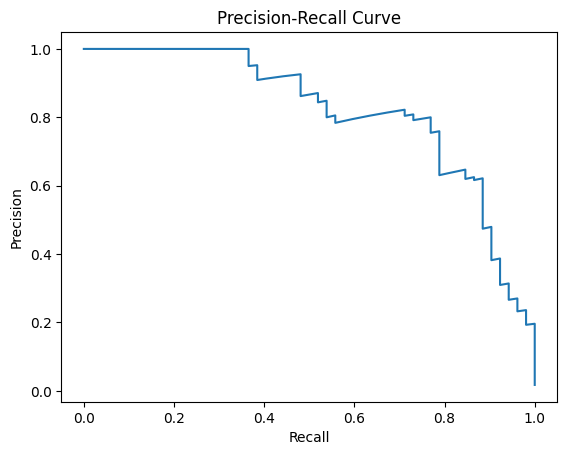

In [26]:
#optimizing curve
precision,recall,threshold=precision_recall_curve(y_test,y_prob)
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [27]:
def calculate_cost(y_true,y_pred):
    cost=0
    for true,pred in zip(y_true,y_pred):
        if true==1 and pred==0:
            cost += 500000
        elif true==0 and pred==1:
            cost += 5000
    return cost
best_cost=float('inf')
best_threshold=0
for t in np.arange(0.1,0.9,0.05):
            y_pred_custom=(y_prob>t).astype(int)
            cost=calculate_cost(y_test,y_pred_custom)

if cost < best_cost:
    best_cost=cost
    best_threshold=t

print("Best_threshold:\n",best_threshold)
print("minimum_cost:\n", best_cost)

                

Best_threshold:
 0.8500000000000002
minimum_cost:
 16500000
